In [1]:
from service.live.model_portfolio import _load_pickles, _filter_grouped
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

abbrs, names, styles, raw = _load_pickles()
# kept_abbr, kept_name, kept_style, _, _, cleaned_raw = _filter_grouped(abbrs, names, styles, raw)

In [10]:
raw[23][3].head(5)

,gvkeyiid,ticker,isin,ddt,sec,country,factorId,factorName,factorShortName,styleName,factorOrder,PM1M,M_RETURN,rank,score,quantile
0,01372101,ZTS,US98978V1035,2021-01-31,Health Care,USA,23,1M Price Reversal,1M Price Reversal,Price Momentum,1,0.025657,-0.067976,76.0,48.292994,Q3
1,14455901,ZBH,US98956P1021,2021-01-31,Health Care,USA,23,1M Price Reversal,1M Price Reversal,Price Momentum,1,0.054689,-0.002726,114.0,72.254777,Q4
2,06541701,YUM,US9884981013,2021-01-31,Consumer Discretionary,USA,23,1M Price Reversal,1M Price Reversal,Price Momentum,1,0.020876,-0.065125,81.0,47.315789,Q3
3,26435101W,YAR,NO0010208051,2021-01-31,Materials,NOR,23,1M Price Reversal,1M Price Reversal,Price Momentum,1,0.025617,0.128051,46.0,38.125000,Q2
4,14499801,XPO,US9837931008,2021-01-31,Industrials,USA,23,1M Price Reversal,1M Price Reversal,Price Momentum,1,0.079515,-0.073742,213.0,84.285714,Q5


In [6]:
abbrs.index("90DCV")

89

In [10]:
t = raw[89][1].copy()
t['spread'] = t['Q1'] - t['Q5']

In [11]:
t

quantile,Q1,Q2,Q3,Q4,Q5,spread
ddt,,,,,,
2017-12-31,0.024365,0.008205,0.005420,0.005609,0.008026,0.016339
2018-01-31,0.017931,0.039165,0.042081,0.041120,0.054090,-0.036159
2018-02-28,-0.051017,-0.043602,-0.039405,-0.047570,-0.043987,-0.007031
2018-03-31,0.017041,0.026660,0.005678,0.008948,0.005140,0.011902
2018-04-30,-0.051372,-0.046183,-0.049810,-0.048964,-0.044649,-0.006723
...,...,...,...,...,...,...
2025-05-31,0.013283,0.020957,0.025235,0.024387,0.028559,-0.015276
2025-06-30,0.082873,0.043461,0.033127,0.018340,0.009806,0.073067
2025-07-31,0.067581,0.042870,0.032151,0.027020,0.033631,0.033950


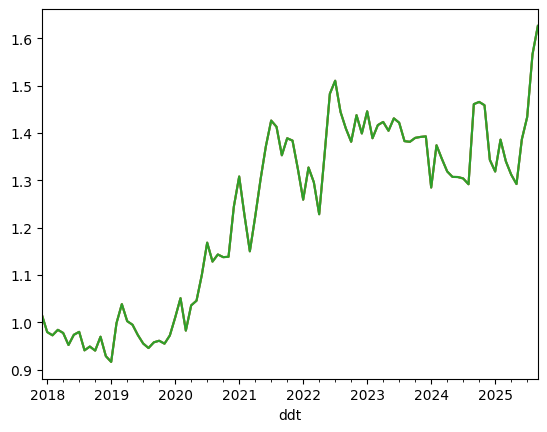

In [14]:
(1 + t['spread']).cumprod().plot()
plt.show()

In [17]:
dd_test = raw[89][3].copy()
dd_test = dd_test[dd_test['ddt'] == '2025-09-30'].reset_index(drop=True)
dd_test

,gvkeyiid,ticker,isin,ddt,sec,country,factorId,factorName,factorShortName,styleName,factorOrder,90DCV,M_RETURN,rank,score,quantile
0,21338001W,000001,CNE000000040,2025-09-30,Financials,CHN,89,90 Day Coefficient of Variation,90DCV,Volatility,0,0.049877,-0.057423,57.0,78.000000,Q4
1,27104801W,000400,CNE0000007F6,2025-09-30,Industrials,CHN,89,90 Day Coefficient of Variation,90DCV,Volatility,0,0.041291,0.139462,65.0,65.000000,Q4
2,24376701W,000568,CNE000000GF2,2025-09-30,Consumer Staples,CHN,89,90 Day Coefficient of Variation,90DCV,Volatility,0,0.057039,-0.036883,9.0,28.310345,Q2
3,25134401W,000629,CNE0000007H2,2025-09-30,Materials,CHN,89,90 Day Coefficient of Variation,90DCV,Volatility,0,0.040201,0.102111,64.0,87.625000,Q5
4,27196601W,000750,CNE0000008K4,2025-09-30,Financials,CHN,89,90 Day Coefficient of Variation,90DCV,Volatility,0,0.070123,-0.007136,26.0,35.375000,Q2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534,31999701W,603979,CNE1000022P2,2025-09-30,Materials,CHN,89,90 Day Coefficient of Variation,90DCV,Volatility,0,0.142389,0.095703,8.0,10.625000,Q1
535,31925501W,603939,CNE100001TS5,2025-09-30,Consumer Staples,CHN,89,90 Day Coefficient of Variation,90DCV,Volatility,0,0.062460,0.039985,6.0,18.068966,Q1
536,33303201W,688012,CNE100003MM9,2025-09-30,Information Technology,CHN,89,90 Day Coefficient of Variation,90DCV,Volatility,0,0.064137,0.398264,72.0,61.594828,Q4
537,34621901W,688617,CNE100004C45,2025-09-30,Health Care,CHN,89,90 Day Coefficient of Variation,90DCV,Volatility,0,0.030060,0.115569,39.0,79.375000,Q4


In [18]:
dd_test.to_csv("90dcv.csv")

In [ ]:
def _ls_portfolio(
        data_raw: pd.DataFrame,
        ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    
    raw_df              = data_raw[data_raw['ddt'] >= '2017-12-31'].reset_index(drop=True).copy()
    raw_df['signal']    = raw_df['label'].map({1: 'L', 0: 'N', -1: 'S'})
    raw_df['num']       = raw_df.groupby(['ddt', 'signal'])['signal'].transform('count')
    raw_df['wgt_rtn']   = 1 / raw_df['num'] * raw_df['label']
    raw_df['wgt_tvr']   = abs(raw_df['wgt_rtn'])
    raw_df_l            = raw_df[raw_df['signal'] == 'L'].reset_index(drop=True)
    raw_df_s            = raw_df[raw_df['signal'] == 'S'].reset_index(drop=True)

    return raw_df_l, raw_df_s


def _vectorized_bt(
    port_raw: pd.DataFrame,
    abbr_nms: List[str],
    cost_bps: float = 10.0) -> pd.DataFrame:
        
    wgt_df              = port_raw.pivot_table(index='ddt', columns='gvkeyiid', values='wgt_rtn')
    rtn_df              = port_raw.pivot_table(index='ddt', columns='gvkeyiid', values='M_RETURN')
    rtn_df.iloc[0]      = 0
    tvr_df              = port_raw.pivot_table(index='ddt', columns='gvkeyiid', values='wgt_tvr').fillna(0)
    sgn_df              = np.sign(wgt_df)

    r                   = rtn_df.sort_index()
    w                   = tvr_df.reindex(r.index)
    w0                  = tvr_df.copy()
    is_rebal            = w.notna().any(axis=1).fillna(False)
    block_id            = is_rebal.cumsum().astype(int)
    cumG_blk            = (1 + sgn_df * r).groupby(block_id).cumprod()

    denom               = (w0 * cumG_blk).sum(axis=1)
    w_pre               = (w0 * cumG_blk).div(denom, axis=0)

    wgt_df.iloc[0]      = w0.loc[wgt_df.index[0]]
    _gross              = (wgt_df * r).sum(axis=1)

    rebal_in_r          = r.index.intersection(tvr_df.index)
    turnover            = 1 * (w.shift(-1).loc[rebal_in_r] - w_pre.loc[rebal_in_r]).abs().sum(axis=1)
    turnover            = turnover.reindex(r.index).fillna(0)
    trading_friction    = (cost_bps / 1e4) * turnover
    _net                = _gross - trading_friction

    return _gross.to_frame().rename(columns={0: abbr_nms}), _net.to_frame().rename(columns={0: abbr_nms}), trading_friction.to_frame().rename(columns={0: abbr_nms})

In [1]:
list_gross  = []
list_net    = []
list_tc     = []

for list_raw, list_abbr in zip(cleaned_raw, kept_abbr):

    dfl, dfs                         = _ls_portfolio(list_raw)
    res_gross_l, res_net_l, res_tc_l = _vectorized_bt(dfl, list_abbr)
    res_gross_s, res_net_s, res_tc_s = _vectorized_bt(dfs, list_abbr)

    list_gross.append(res_gross_l + res_gross_s)
    list_net.append(res_net_l + res_net_s)
    list_tc.append(res_tc_l + res_tc_s)

NameError: name 'cleaned_raw' is not defined

In [ ]:
df_gross = pd.concat(list_gross, axis=1).dropna(axis=1)
df_net   = pd.concat(list_net, axis=1).dropna(axis=1)
df_tc    = pd.concat(list_tc, axis=1).dropna(axis=1)

In [111]:
cagr = (1 + df_net).cumprod()[-1:] ** (12 / 94) - 1
cagr = cagr.T
cagr.columns = ['gmean']

In [112]:
cagr.sort_values('gmean', ascending=False)[:10]

,gmean
SalesAcc,0.088432
52WSlope,0.087451
6MTTMSalesMom,0.079497
PM6M,0.078723
RevMagFY1C,0.077290
Chg1YOCF,0.076988
Rev3MFY1C,0.075792
PM12M1M,0.074792
3MSalesMom,0.074482
Rev3MFY2C,0.073619
